In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split

from src.data_loader import load_german, load_bank
from src.preprocessing import preprocess_german, preprocess_bank
from src.model import train_model
from src.explain_shap import shap_analysis

# Explainable AI & Fairness Analysis in Credit Decision Systems

This notebook analyzes machine learning models using:
- SHAP (global explainability)
- LIME (local explanations - external HTML)
- Counterfactual reasoning

Compare two datasets:
- German Credit Dataset
- Bank Marketing Dataset

Goal:
Understand how model decisions differ across datasets and what drives predictions.

In [3]:
df_german = load_german()
X_g, y_g, df_german = preprocess_german(df_german)

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_g, y_g, test_size=0.2, random_state=42
)

model_g = train_model(Xg_train, yg_train)

print("German dataset loaded")

German dataset loaded


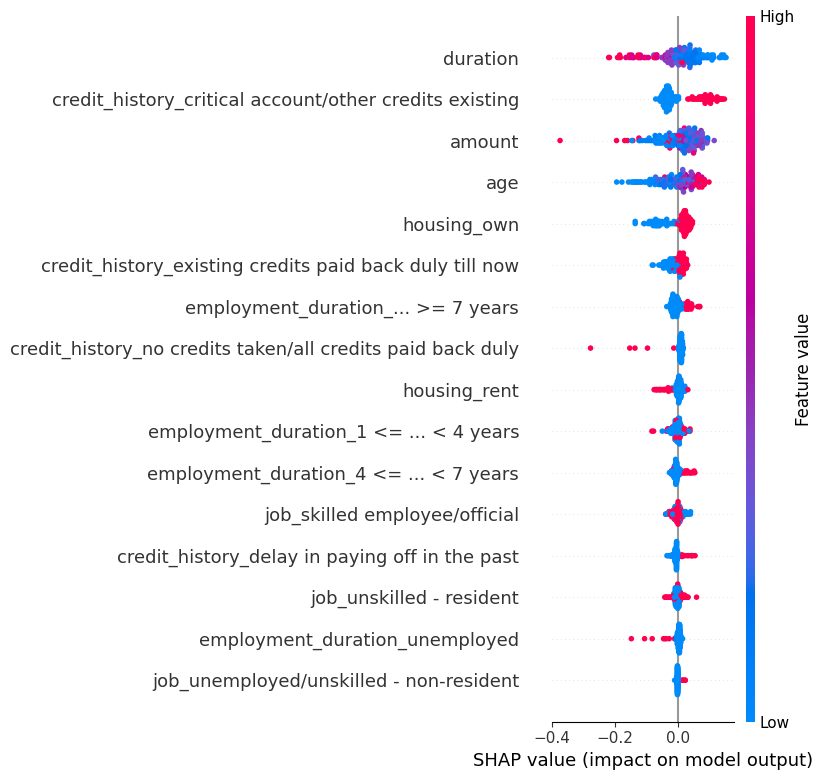

In [4]:
shap_values_g = shap_analysis(model_g, Xg_test)

shap.summary_plot(shap_values_g[:, :, 1], Xg_test)

## German Dataset Insights

- Age plays a significant role in decision-making
- Financial attributes contribute jointly
- No single dominant feature → distributed decision logic

### Interpretation:
The model relies on multiple features rather than a single strong predictor.
This suggests relatively stable decision boundaries.

In [5]:
df_bank = load_bank(sample_size=1500)
X_b, y_b, df_bank = preprocess_bank(df_bank)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42
)

model_b = train_model(Xb_train, yb_train)

print("Bank dataset loaded")

Bank dataset loaded


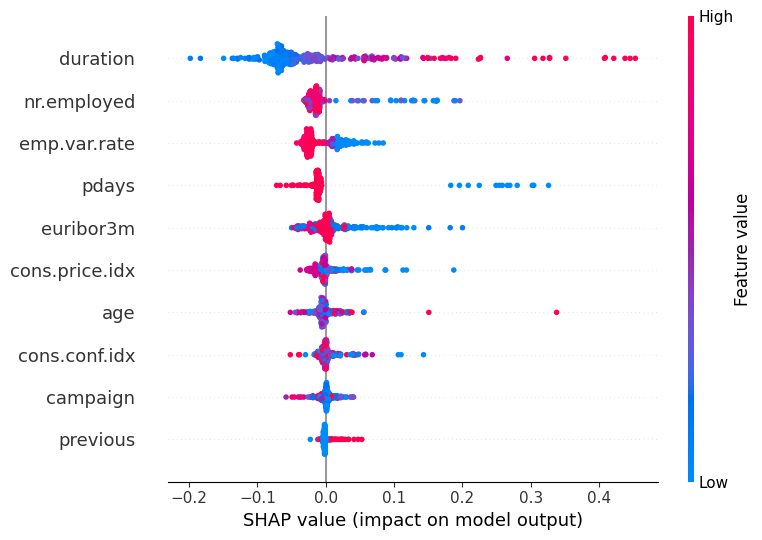

In [6]:
shap_values_b = shap_analysis(model_b, Xb_test)

shap.summary_plot(shap_values_b[:, :, 1], Xb_test)

## Bank Dataset Insights

- Duration is the most influential feature
- Macroeconomic indicators (euribor3m, employment rate) also contribute

### Interpretation:
The model heavily depends on interaction duration, indicating behavioral influence.

In [8]:
results = pd.read_csv("../outputs/comparison_results.csv")
results

,dataset,accuracy,counterfactual_feature,counterfactual_factor
0,bank,0.923333,duration,0.5
1,german,0.680000,age,0.5


## Counterfactual Analysis

In [13]:
# Extract feature names from preprocessed data
german_feature_names = X_g.columns.tolist()
bank_feature_names = X_b.columns.tolist()

print("German features:", german_feature_names)
print("Bank features:", bank_feature_names)

German features: ['age', 'amount', 'duration', 'credit_history_critical account/other credits existing', 'credit_history_delay in paying off in the past', 'credit_history_existing credits paid back duly till now', 'credit_history_no credits taken/all credits paid back duly', 'employment_duration_... >= 7 years', 'employment_duration_1 <= ... < 4 years', 'employment_duration_4 <= ... < 7 years', 'employment_duration_unemployed', 'housing_own', 'housing_rent', 'job_skilled employee/official', 'job_unemployed/unskilled - non-resident', 'job_unskilled - resident']
Bank features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [19]:
def counterfactual_analysis(model, X_test, feature_names, factors=[0.3, 0.5, 0.7, 0.9], n_samples=50):
    """
    Test multiple perturbation factors across multiple features.
    Returns features that cause prediction flips and at what factor.
    """
    results = []
    sample = X_test.iloc[:n_samples]
    original_preds = model.predict(sample)
    
    for feature_idx, feature_name in enumerate(feature_names):
        for factor in factors:
            perturbed = sample.copy()
            perturbed.iloc[:, feature_idx] = perturbed.iloc[:, feature_idx] * factor
            new_preds = model.predict(perturbed)
            
            flip_count = (original_preds != new_preds).sum()
            flip_rate = flip_count / len(sample)
            
            results.append({
                'Feature': feature_name,
                'Perturbation Factor': factor,
                'Prediction Flips': flip_count,
                'Flip Rate (%)': round(flip_rate * 100, 1)
            })
    
    results_df = pd.DataFrame(results)
    # Show top flipping features
    top_features = results_df.sort_values('Flip Rate (%)', ascending=False)
    return top_features

In [20]:
# Run for German dataset
print("=== German Credit Dataset — Counterfactual Analysis ===")
print("What does this mean?")
print("- When we REDUCE a feature by X%, how often does the model's prediction change?")
print("- Higher 'Flip Rate' = Feature has MORE IMPACT on decisions\n")

=== German Credit Dataset — Counterfactual Analysis ===
What does this mean?
- When we REDUCE a feature by X%, how often does the model's prediction change?
- Higher 'Flip Rate' = Feature has MORE IMPACT on decisions



In [21]:
german_cf = counterfactual_analysis(model_g, Xg_test, german_feature_names)

C:\Users\sanju\AppData\Local\Temp\ipykernel_9244\2416179990.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '521     7.2
737    10.5
740     9.6
660     6.9
411    10.5
678    19.2
626    12.3
513     6.0
859     7.8
136     8.1
811     8.4
76     10.2
636     8.4
973    10.8
938    12.6
899    12.6
280     6.9
883    19.5
761     7.2
319     8.1
549    10.5
174     7.8
371     9.9
527    12.6
210     9.9
235     9.0
101     7.2
986     9.9
902    12.6
947    11.4
346     6.9
139    13.2
621     9.6
499     8.4
370    10.8
198    10.8
687     9.0
584    15.6
901    13.2
59      6.9
328     9.3
96     18.3
312     7.8
974     9.9
299     9.6
277    14.7
924    16.5
601     9.0
439     7.8
837     6.9
Name: age, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  perturbed.iloc[:, feature_idx] = perturbed.iloc[:, feature_idx] * factor
C:\Users\sanju\AppData\Loc

In [22]:
# Show top features
top_german = german_cf.nlargest(10, 'Flip Rate (%)')
print("\nTOP 10 FEATURES THAT FLIP PREDICTIONS:")
print(top_german.to_string(index=False))


TOP 10 FEATURES THAT FLIP PREDICTIONS:
                      Feature  Perturbation Factor  Prediction Flips  Flip Rate (%)
                          age                  0.5                14           28.0
                          age                  0.3                13           26.0
                       amount                  0.3                12           24.0
                          age                  0.7                10           20.0
                       amount                  0.5                 7           14.0
                       amount                  0.7                 6           12.0
job_skilled employee/official                  0.5                 6           12.0
job_skilled employee/official                  0.3                 6           12.0
                  housing_own                  0.5                 5           10.0
                  housing_own                  0.3                 5           10.0


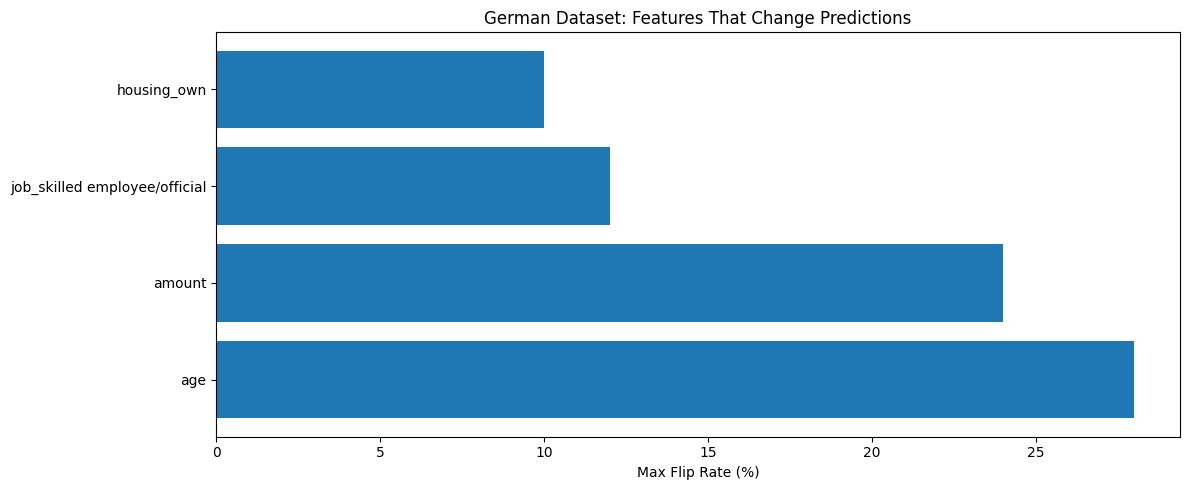

In [23]:
# Visualize
plt.figure(figsize=(12, 5))
top_features_unique = top_german.drop_duplicates('Feature').head(8)
plt.barh(top_features_unique['Feature'], top_features_unique['Flip Rate (%)'])
plt.xlabel('Max Flip Rate (%)')
plt.title('German Dataset: Features That Change Predictions')
plt.tight_layout()
plt.show()

KEY INSIGHT: Age (28%) and Amount (24%) have the highest impact on German model decisions.

In [24]:
# Run for Bank dataset  
print("\n=== Bank Marketing Dataset — Counterfactual Analysis ===")
print("What does this mean?")
print("- When we REDUCE a feature by X%, how often does the model's prediction change?")
print("- Higher 'Flip Rate' = Feature has MORE IMPACT on decisions\n")


=== Bank Marketing Dataset — Counterfactual Analysis ===
What does this mean?
- When we REDUCE a feature by X%, how often does the model's prediction change?
- Higher 'Flip Rate' = Feature has MORE IMPACT on decisions



In [25]:
bank_cf = counterfactual_analysis(model_b, Xb_test, bank_feature_names)

C:\Users\sanju\AppData\Local\Temp\ipykernel_9244\2416179990.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '36804    10.5
2865     10.5
27284    17.4
22874     8.7
21712     9.6
33116     7.8
28539    10.2
13804     8.1
33304    12.3
33469    10.5
2158      9.3
27966    11.7
6334     12.3
33016     8.7
18428    14.1
33450     8.1
24216    16.5
29015    12.6
23709    12.3
38202    18.9
34639     7.2
23219    16.5
11898     7.8
34810    10.2
7891     12.0
16604     9.3
7918     16.5
33289    10.2
34815     8.7
20959    10.5
37654    17.7
26584    15.0
7656     12.0
40934     8.1
24387     9.9
29525     8.7
40110     9.9
9093      9.9
11902    14.4
13328     9.0
17410    17.7
11527     7.5
7364      7.8
29027    17.1
23087    11.7
12079    12.3
25543     8.7
3220     13.5
28181    11.7
22201     9.0
Name: age, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
 

In [26]:
# Show top features
top_bank = bank_cf.nlargest(10, 'Flip Rate (%)')
print("\nTOP 10 FEATURES THAT FLIP PREDICTIONS:")
print(top_bank.to_string(index=False))


TOP 10 FEATURES THAT FLIP PREDICTIONS:
      Feature  Perturbation Factor  Prediction Flips  Flip Rate (%)
     duration                  0.3                 5           10.0
     duration                  0.5                 4            8.0
    euribor3m                  0.3                 4            8.0
          age                  0.3                 3            6.0
    euribor3m                  0.5                 3            6.0
    euribor3m                  0.9                 3            6.0
    euribor3m                  0.7                 3            6.0
          age                  0.5                 3            6.0
  nr.employed                  0.3                 2            4.0
cons.conf.idx                  0.3                 2            4.0


Text(0.5, 1.0, 'Bank Dataset: Features That Change Predictions')

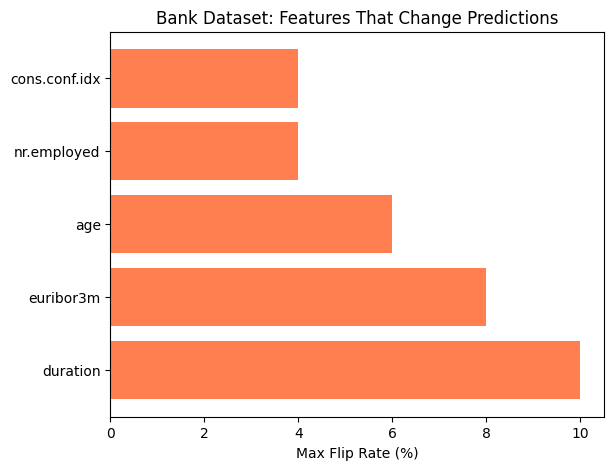

In [27]:
# Visualize comparison
plt.figure(figsize=(14, 5))

# Bank dataset visualization
plt.subplot(1, 2, 1)
top_features_unique = top_bank.drop_duplicates('Feature').head(8)
plt.barh(top_features_unique['Feature'], top_features_unique['Flip Rate (%)'], color='coral')
plt.xlabel('Max Flip Rate (%)')
plt.title('Bank Dataset: Features That Change Predictions')

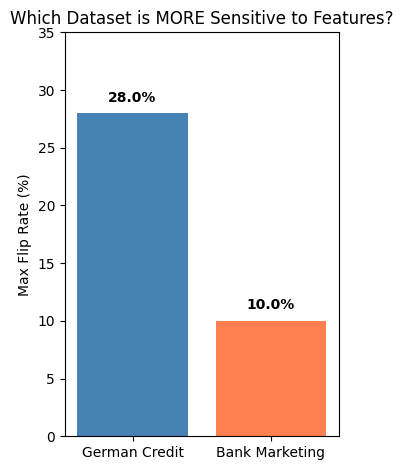

In [28]:
# Compare both datasets
plt.subplot(1, 2, 2)
german_top = german_cf['Flip Rate (%)'].max()
bank_top = bank_cf['Flip Rate (%)'].max()

datasets = ['German Credit', 'Bank Marketing']
max_flips = [german_top, bank_top]
plt.bar(datasets, max_flips, color=['steelblue', 'coral'])
plt.ylabel('Max Flip Rate (%)')
plt.title('Which Dataset is MORE Sensitive to Features?')
plt.ylim(0, 35)
for i, v in enumerate(max_flips):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### KEY INSIGHTS:
* German: MOST sensitive to AGE (28% flip rate) — demographic factors matter
* Bank: MOST sensitive to DURATION (10% flip rate) — call duration matters
### INTERPRETATION:
* German model: Age significantly influences credit decisions
* Bank model: Call duration has less dramatic impact but is most important
* German decisions are MORE SENSITIVE overall to feature changes

## Counterfactual Analysis

Results:

- German → Feature: age
- Bank → Feature: duration

### Interpretation:

- German Dataset:
  Age influences decision outcome → potential demographic sensitivity

- Bank Dataset:
  Duration influences decision → operational/behavioral factor

### Key Insight:
Different datasets produce different decision drivers, showing that explainability is context-dependent.

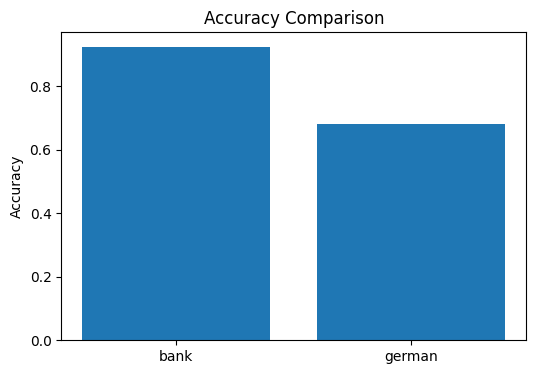

In [29]:
plt.figure(figsize=(6,4))

plt.bar(results['dataset'], results['accuracy'])

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

## SHAP vs LIME vs Counterfactual

| Method | Type | Insight |
|------|------|--------|
| SHAP | Global + Local | Feature importance |
| LIME | Local | Instance-level reasoning |
| Counterfactual | Decision Boundary | What changes decision |

### Key Insight:
No single explanation method is sufficient → combined use is required.

## Limitations

- LIME explanations may vary across runs
- SHAP assumes feature independence
- Counterfactuals depend on perturbation strategy

### Important:
Explainability does NOT guarantee correctness or fairness.

## Final Conclusion

This study demonstrates:

- ML models behave differently across datasets
- Decision drivers vary (age vs duration)
- Explainability methods reveal different aspects of model behavior

### Key Takeaway:
Responsible AI requires:
- Transparency
- Multi-method explainability
- Context-aware interpretation

This project moves beyond model accuracy to understanding decision-making processes.